# 🏆 2026 FIFA World Cup Predictor: Feature Engineering Pipeline
This notebook processes raw international football match data into a machine learning-ready feature matrix.

In [37]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore') # Keeps the notebook clean from pandas slice warnings

## Step 1: Base Cleaning & Target Configuration
This function handles formatting dates, defining the win/draw/loss target, merging penalty shootout data, and engineering tournament weights and host advantages.

In [38]:
def load_and_clean_data(results_path, shootouts_path):
    # Load datasets
    df = pd.read_csv(results_path)
    shootouts = pd.read_csv(shootouts_path)
    
    # Format dates
    df['date'] = pd.to_datetime(df['date'])
    shootouts['date'] = pd.to_datetime(shootouts['date'])
    
    # Sort chronologically
    df = df.sort_values('date').reset_index(drop=True)
    
    # Target Calculations & Goal Difference
    df['goal_difference'] = df['home_score'] - df['away_score']
    
    conditions = [
        (df['home_score'] > df['away_score']),
        (df['home_score'] == df['away_score']),
        (df['home_score'] < df['away_score'])
    ]
    df['outcome'] = np.select(conditions, [2, 1, 0])
    
    # Incorporate penalty shootout results
    df = df.merge(shootouts[['date', 'home_team', 'away_team', 'winner']], 
                  on=['date', 'home_team', 'away_team'], how='left')
    df.loc[(df['outcome'] == 1) & (df['winner'] == df['home_team']), 'outcome'] = 2
    df.loc[(df['outcome'] == 1) & (df['winner'] == df['away_team']), 'outcome'] = 0
    df.drop(columns=['winner'], inplace=True)
    
    # Match Context & Tournament Weights
    tournament_weights = {
        'Friendly': 1, 'FIFA World Cup qualification': 2, 'UEFA Euro qualification': 2,
        'Copa América qualification': 2, 'African Cup of Nations qualification': 2,
        'CONCACAF Nations League': 2, 'UEFA Nations League': 2, 'AFC Asian Cup': 3,
        'African Cup of Nations': 3, 'Copa América': 3, 'UEFA Euro': 3,
        'CONCACAF Gold Cup': 3, 'FIFA World Cup': 4
    }
    df['match_importance'] = df['tournament'].map(tournament_weights).fillna(1)
    
    # 2026 Host Advantage Override
    hosts_2026 = ['United States', 'Mexico', 'Canada']
    df.loc[(df['home_team'].isin(hosts_2026)) & (df['country'] == df['home_team']), 'neutral'] = False
    df.loc[(df['away_team'].isin(hosts_2026)) & (df['country'] == df['away_team']), 'neutral'] = False
    df['home_has_advantage'] = np.where(df['neutral'] == False, 1, 0)
    
    return df

## Step 2: Team Rolling Features
Calculates rolling momentum variables chronologically (win rates, goals scored/conceded, and days of rest).

In [39]:
def build_team_rolling_features(df, window=5):
    home_df = df[['date', 'home_team', 'home_score', 'away_score', 'outcome']].copy()
    home_df.columns = ['date', 'team', 'goals_scored', 'goals_conceded', 'match_result']
    home_df['is_win'] = (home_df['match_result'] == 2).astype(int)
    
    away_df = df[['date', 'away_team', 'away_score', 'home_score', 'outcome']].copy()
    away_df.columns = ['date', 'team', 'goals_scored', 'goals_conceded', 'match_result']
    away_df['is_win'] = (away_df['match_result'] == 0).astype(int)
    
    team_timeline = pd.concat([home_df, away_df]).sort_values(['team', 'date']).reset_index(drop=True)
    
    team_timeline['days_rest'] = team_timeline.groupby('team')['date'].diff().dt.days.fillna(30)
    team_timeline['days_rest'] = team_timeline['days_rest'].clip(upper=30)
    
    grouped = team_timeline.groupby('team')
    
    team_timeline['win_rate'] = grouped['is_win'].shift(1).rolling(window, min_periods=1).mean().reset_index(0, drop=True)
    team_timeline['avg_goals_scored'] = grouped['goals_scored'].shift(1).rolling(window, min_periods=1).mean().reset_index(0, drop=True)
    team_timeline['avg_goals_conceded'] = grouped['goals_conceded'].shift(1).rolling(window, min_periods=1).mean().reset_index(0, drop=True)
    
    team_timeline['win_rate'] = team_timeline['win_rate'].fillna(0.33)
    team_timeline['avg_goals_scored'] = team_timeline['avg_goals_scored'].fillna(1.0)
    team_timeline['avg_goals_conceded'] = team_timeline['avg_goals_conceded'].fillna(1.0)
    
    home_features = team_timeline.add_prefix('home_').rename(columns={'home_date': 'date', 'home_team': 'home_team'})
    away_features = team_timeline.add_prefix('away_').rename(columns={'away_date': 'date', 'away_team': 'away_team'})
    
    df = df.merge(home_features[['date', 'home_team', 'home_days_rest', 'home_win_rate', 'home_avg_goals_scored', 'home_avg_goals_conceded']], on=['date', 'home_team'], how='left')
    df = df.merge(away_features[['date', 'away_team', 'away_days_rest', 'away_win_rate', 'away_avg_goals_scored', 'away_avg_goals_conceded']], on=['date', 'away_team'], how='left')
    
    return df

## Step 3: Head-to-Head Features
Computes historical dominance and rivalry tracking between specific pairings.

In [40]:
def build_head_to_head_features(df):
    df['pair'] = df.apply(lambda row: tuple(sorted([row['home_team'], row['away_team']])), axis=1)
    
    df['h2h_home_wins'] = 0
    df['h2h_total_matches'] = 0
    df['h2h_cumulative_goal_diff'] = 0.0
    
    pair_history = {}
    
    for idx, row in df.iterrows():
        pair = row['pair']
        home = row['home_team']
        gd = row['goal_difference']
        outcome = row['outcome']
        
        if pair not in pair_history:
            pair_history[pair] = {'total': 0, 'home_wins_count': 0, 'cum_gd': 0.0}
            
        stats = pair_history[pair]
        
        if stats['total'] > 0:
            df.at[idx, 'h2h_total_matches'] = stats['total']
            df.at[idx, 'h2h_home_win_percentage'] = stats['home_wins_count'] / stats['total']
            df.at[idx, 'h2h_goal_diff_historical'] = stats['cum_gd']
        else:
            df.at[idx, 'h2h_total_matches'] = 0
            df.at[idx, 'h2h_home_win_percentage'] = 0.5
            df.at[idx, 'h2h_goal_diff_historical'] = 0.0
            
        stats['total'] += 1
        stats['cum_gd'] += gd if home == row['home_team'] else -gd
        if outcome == 2:
            stats['home_wins_count'] += 1
            
    df.drop(columns=['pair', 'h2h_home_wins'], inplace=True)
    return df

## Step 4: Execute Pipeline
Run the pipeline to generate the final feature matrix (`X`) and target variable (`y`).

In [41]:
# 1. Load data 
# Make sure 'results.csv' and 'shootouts.csv' are in the same folder as this notebook
base_df = load_and_clean_data('./data/results.csv', './data/shootouts.csv')

# 2. Build rolling features (Using a 5-match window)
model_ready_df = build_team_rolling_features(base_df, window=15)

# 3. Build head-to-head features
model_ready_df = build_head_to_head_features(model_ready_df)

# 4. Define final matrix
predictor_columns = [
    'home_has_advantage', 'match_importance',
    'home_days_rest', 'home_win_rate', 'home_avg_goals_scored', 'home_avg_goals_conceded',
    'away_days_rest', 'away_win_rate', 'away_avg_goals_scored', 'away_avg_goals_conceded',
    'h2h_total_matches', 'h2h_home_win_percentage', 'h2h_goal_diff_historical'
]

X = model_ready_df[predictor_columns]
y = model_ready_df['outcome']

# Display results
print(f"Pipeline executed successfully!")
print(f"Feature Matrix Shape: {X.shape}")
X.head()

Pipeline executed successfully!
Feature Matrix Shape: (49819, 13)


,home_has_advantage,match_importance,home_days_rest,home_win_rate,home_avg_goals_scored,home_avg_goals_conceded,away_days_rest,away_win_rate,away_avg_goals_scored,away_avg_goals_conceded,h2h_total_matches,h2h_home_win_percentage,h2h_goal_diff_historical
0,1,1.0,30.0,0.384615,1.083333,1.333333,30.0,0.571429,2.214286,1.357143,0,0.500000,0.0
1,1,1.0,30.0,0.500000,1.642857,1.285714,30.0,0.384615,1.083333,1.166667,1,0.000000,0.0
2,1,1.0,30.0,0.307692,1.083333,1.416667,30.0,0.500000,1.714286,1.357143,2,0.500000,2.0
3,1,1.0,30.0,0.428571,1.571429,1.428571,30.0,0.307692,1.000000,1.416667,3,0.666667,3.0
4,1,1.0,30.0,0.307692,1.166667,1.500000,30.0,0.428571,1.714286,1.500000,4,0.500000,3.0


## Step 5: Player Ratings Integration
This section loads the EA FC 26 player data, aggregates the top 18 players for each country to simulate a matchday squad, and merges their overall and potential ratings into the main historical dataframe.

In [42]:
# 1. Load the EA FC 26 Player Data
players_df = pd.read_csv('./data/fc26_players.csv')

# 2. Filter for the top 18 players per country (simulating a matchday squad)
top_players = players_df.sort_values(by='overall', ascending=False).groupby('nationality_name').head(18)

# 3. Calculate team-level metrics
team_strengths = top_players.groupby('nationality_name').agg(
    team_mean_overall=('overall', 'mean'),
    team_max_overall=('overall', 'max'),
    team_mean_potential=('potential', 'mean')
).reset_index()

team_strengths.rename(columns={'nationality_name': 'team'}, inplace=True)

# 4. Map spelling differences between the two Kaggle datasets
name_mapping = {
    'United States': 'USA',
    'Republic of Ireland': 'Ireland',
    'Korea Republic': 'South Korea',
    'Czech Republic': 'Czechia'
}
team_strengths['team'] = team_strengths['team'].replace(name_mapping)

# 5. Merge the new features into the main historical dataframe
model_ready_df = model_ready_df.merge(
    team_strengths.add_prefix('home_'), 
    left_on='home_team', right_on='home_team', how='left'
)

model_ready_df = model_ready_df.merge(
    team_strengths.add_prefix('away_'), 
    left_on='away_team', right_on='away_team', how='left'
)

# 6. Fill missing values (for teams not in the video game) with a low baseline
fill_values = {
    'home_team_mean_overall': 65.0, 'home_team_max_overall': 70.0, 'home_team_mean_potential': 68.0,
    'away_team_mean_overall': 65.0, 'away_team_max_overall': 70.0, 'away_team_mean_potential': 68.0
}
model_ready_df.fillna(value=fill_values, inplace=True)

# 7. Add the new columns to the predictor list for XGBoost
predictor_columns.extend([
    'home_team_mean_overall', 'home_team_max_overall', 'home_team_mean_potential',
    'away_team_mean_overall', 'away_team_max_overall', 'away_team_mean_potential'
])

print(f"Player ratings successfully merged! New Matrix Shape: {model_ready_df.shape}")

Player ratings successfully merged! New Matrix Shape: (49819, 31)


## Step 6: XGBoost Model Training
This section performs a final safety clean, executes a chronological train/test split to prevent data leakage, and trains the XGBoost classifier on the combined feature matrix.

Training XGBoost model on historical and player rating data...

✅ Model Trained! Accuracy on unseen recent matches: 58.66%

Classification Report (0: Away Win, 1: Draw, 2: Home Win):
              precision    recall  f1-score   support

           0       0.58      0.52      0.55      1433
           1       0.18      0.01      0.02       963
           2       0.60      0.88      0.71      2256

    accuracy                           0.59      4652
   macro avg       0.45      0.47      0.42      4652
weighted avg       0.50      0.59      0.52      4652



<Figure size 1000x600 with 0 Axes>

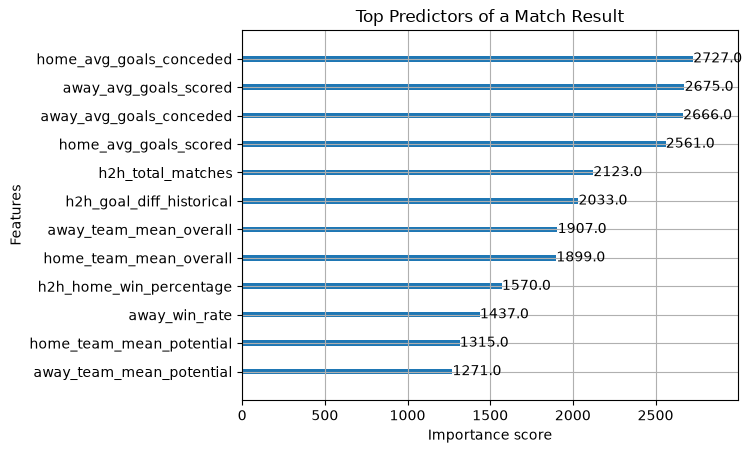

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. Final Clean
# Drop any rows where rolling averages or player ratings couldn't be calculated safely
final_df = model_ready_df.dropna(subset=predictor_columns).copy()

# 2. Chronological Train/Test Split (Avoid Data Leakage)
# Train on historical data (Before 2022)
train_df = final_df[final_df['date'].dt.year < 2022]
# Test on recent data including the 2022 World Cup (2022 - Present)
test_df = final_df[final_df['date'].dt.year >= 2022]

X_train = train_df[predictor_columns]
y_train = train_df['outcome']
X_test = test_df[predictor_columns]
y_test = test_df['outcome']

# 3. Initialize the XGBoost Classifier
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=400,
    random_state=42
)

# 4. Train the Model
print("Training XGBoost model on historical and player rating data...")
model.fit(X_train, y_train)

# 5. Evaluate Performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Model Trained! Accuracy on unseen recent matches: {accuracy * 100:.2f}%\n")
print("Classification Report (0: Away Win, 1: Draw, 2: Home Win):")
print(classification_report(y_test, y_pred))

# 6. Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight', max_num_features=12, title='Top Predictors of a Match Result')
plt.show()